In [1]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs , load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = load_iris(as_frame=True).frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


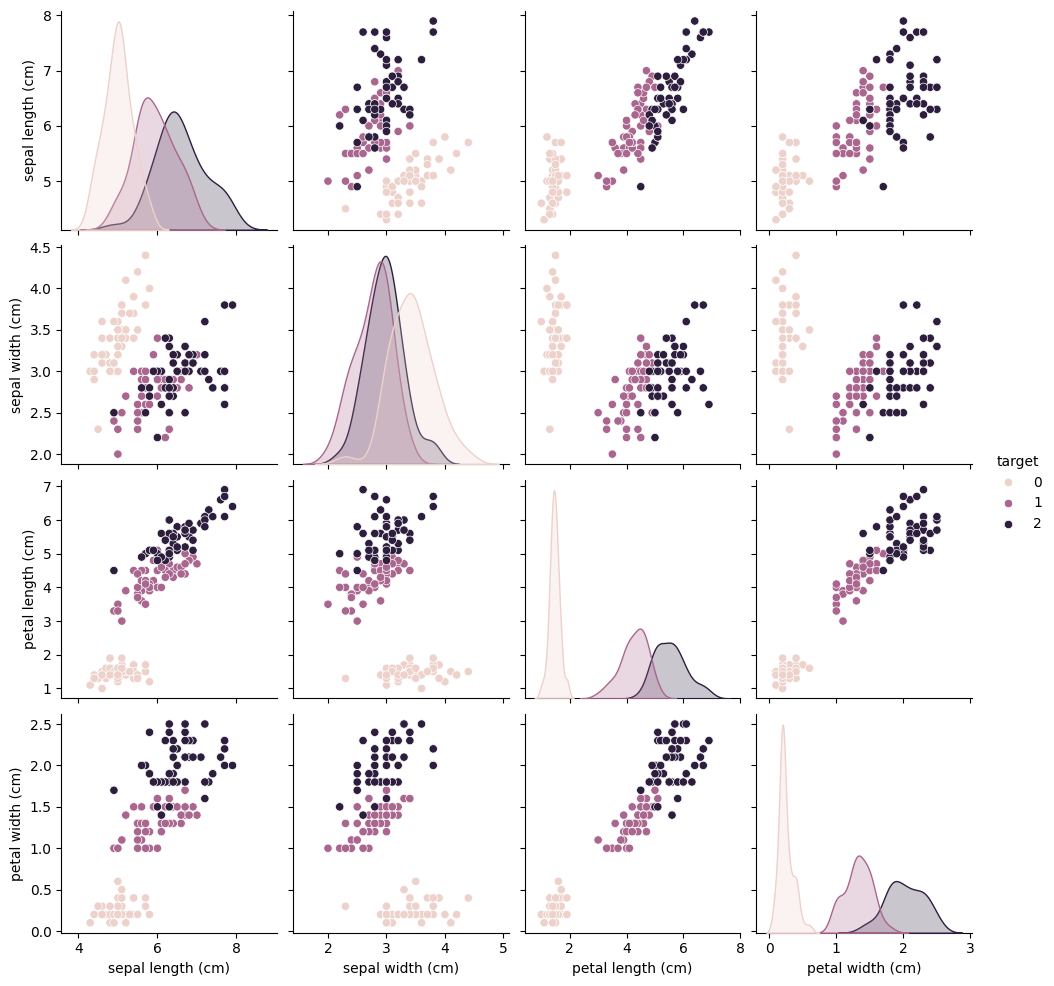

In [4]:
sns.pairplot(df ,hue='target')

In [7]:
y = df['target']
X = df.drop('target' ,axis=1)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.svm import SVC

In [11]:
X_train ,X_test ,y_train ,y_test = train_test_split(X ,y ,test_size=0.2 ,random_state=42)

In [17]:
clf1 = KNeighborsClassifier(n_neighbors=3)
clf1.fit(X_train ,y_train)
print(clf1.score(X_test ,y_test))
print(classification_report(y_test , clf1.predict(X_test)))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



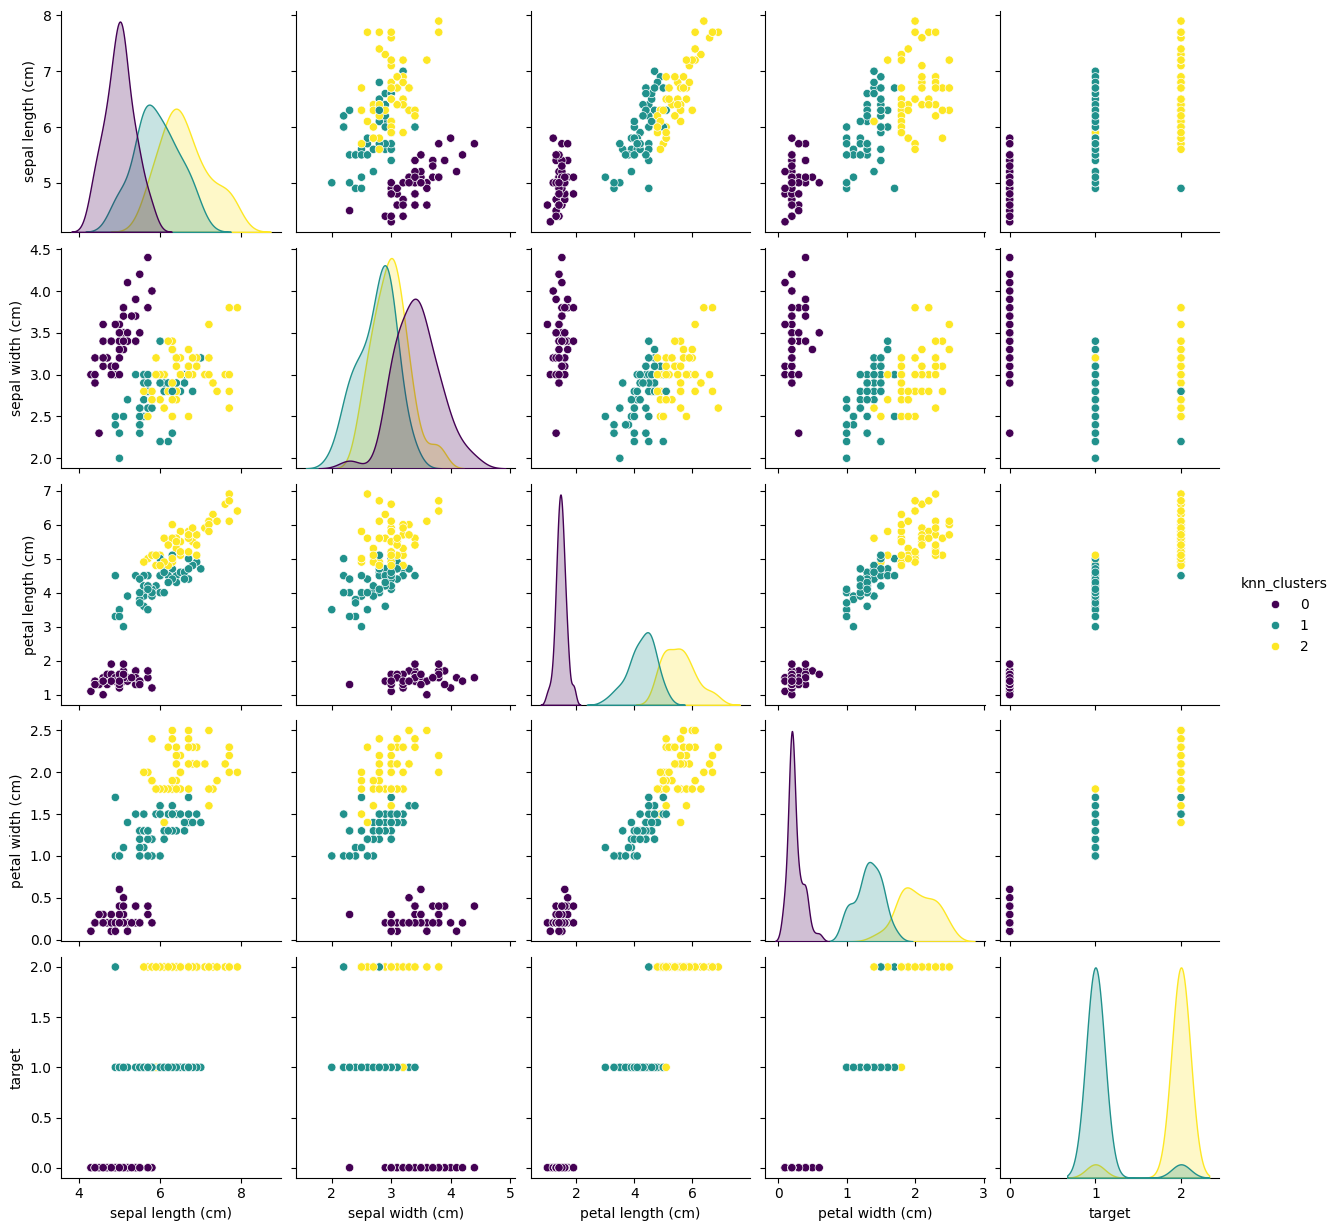

In [13]:
df_knn = df.copy()
df_knn['knn_clusters'] = clf1.predict(X)
sns.pairplot(df_knn, hue='knn_clusters', palette='viridis')

In [18]:
clf2 = SVC()
clf2.fit(X_train ,y_train)
print(clf2.score(X_test ,y_test))
print(classification_report(y_test , clf2.predict(X_test)))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



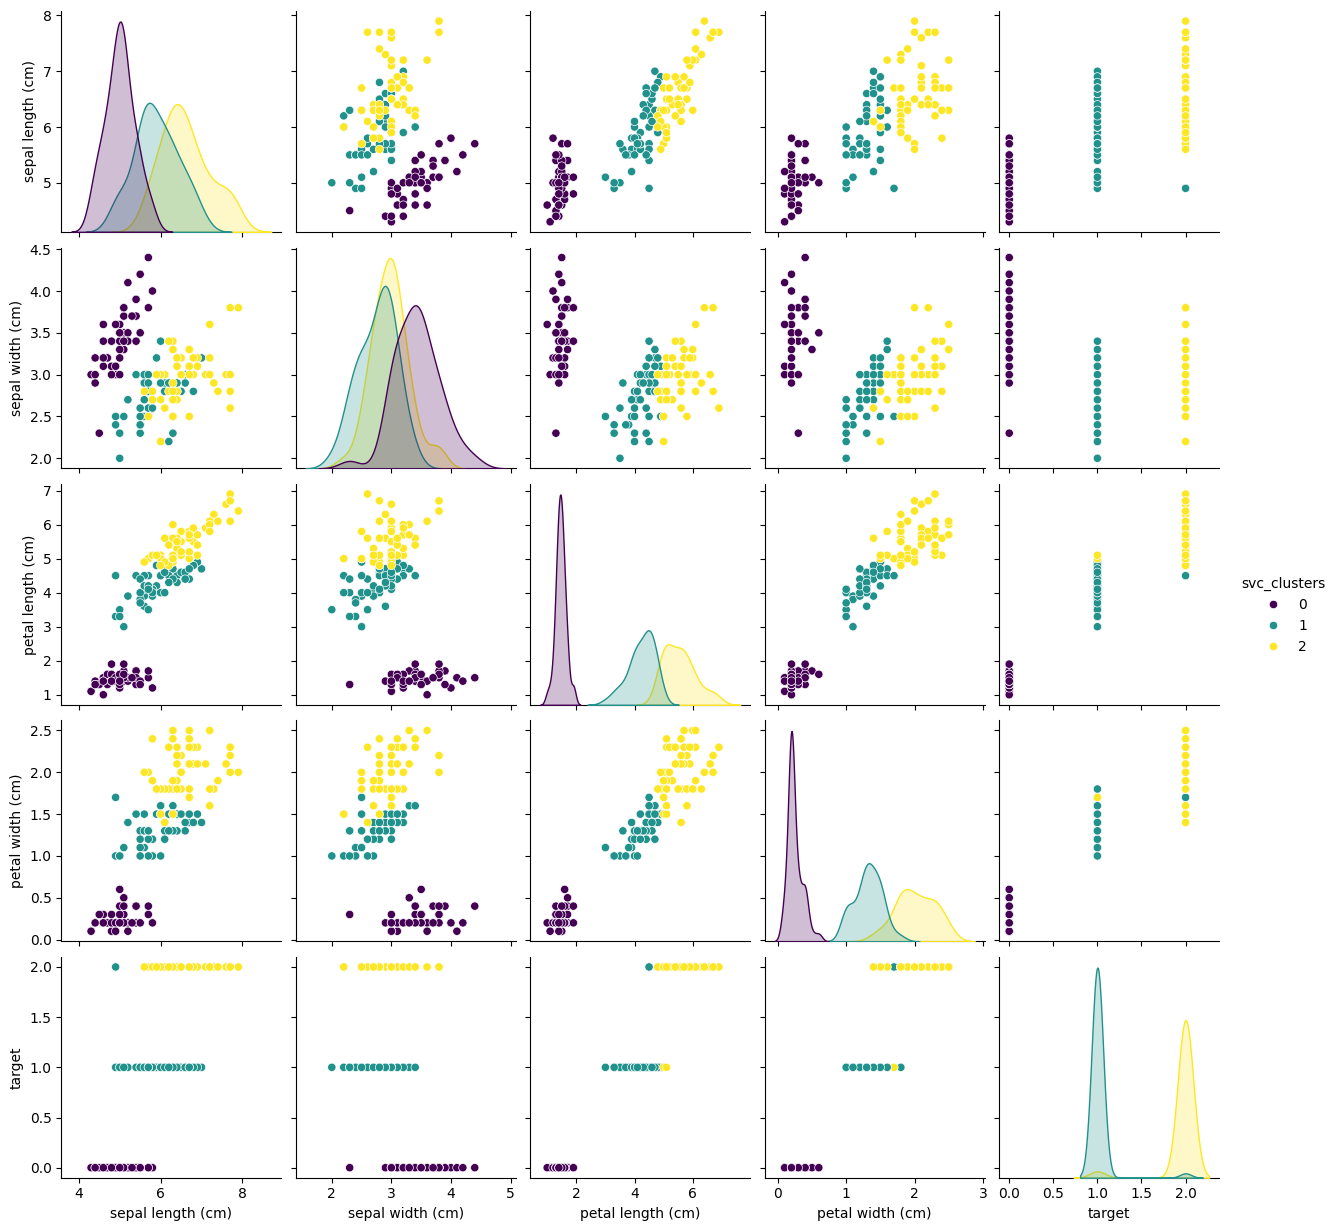

In [20]:
df_svc = df.copy()
df_svc['svc_clusters'] = clf2.predict(X)
sns.pairplot(df_svc, hue='svc_clusters', palette='viridis')

In [21]:
clf3 = DBSCAN()
clf3.fit(X)
print(clf3.labels_)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1  1  1  1  1  1 -1 -1  1 -1 -1  1  1  1  1  1  1  1 -1 -1  1
  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1 -1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


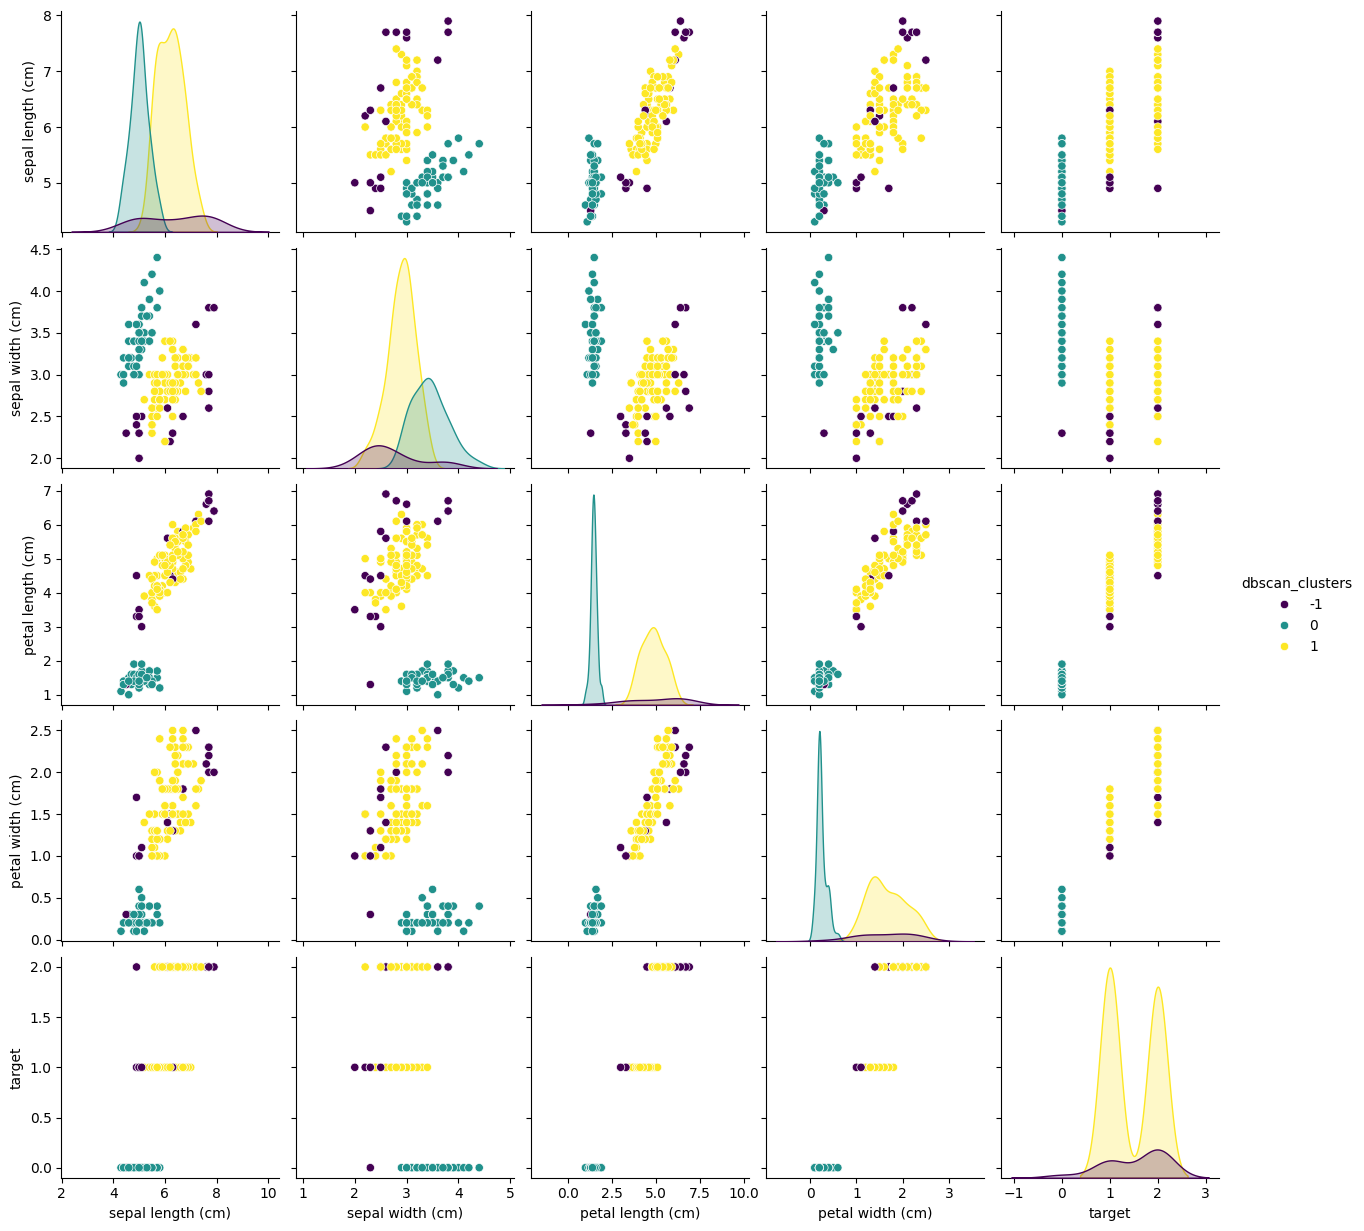

In [22]:
df_dbscan = df.copy()
df_dbscan['dbscan_clusters'] = clf3.labels_
sns.pairplot(df_dbscan, hue='dbscan_clusters', palette='viridis')

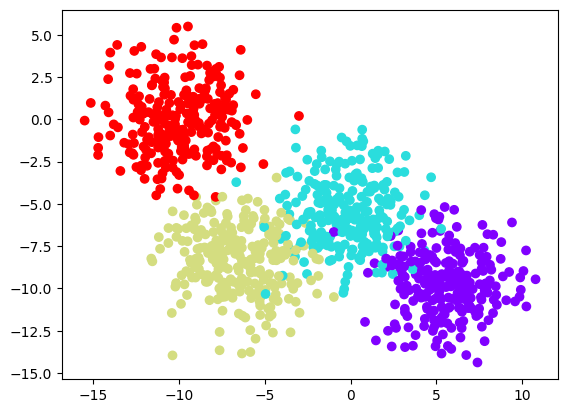

In [33]:
data = make_blobs(n_samples=1000, centers=4, n_features=4, random_state=10 , cluster_std=2)
plt.scatter(data[0][:,0], data[0][:,1],c=data[1], cmap='rainbow')


In [54]:
clf3 = DBSCAN(eps=2 , min_samples=4)
clf3.fit(data[0])
print(clf3.labels_)

[ 0  1  1  0  2 -1  2  0  1  2  2  0  1  3 -1  1  3  3  1  2  3  1  0  3
  1  3  0  1  0  3  3  1  2  3  0  1  3  1  1 -1 -1  0  0  0  2  2  0  0
  1  3 -1  2  0  1 -1  3  0  3  2  2 -1  3 -1  0  1 -1  1  0  0 -1  2  0
  1  2  0  2  3  1  0  3  2  2 -1  3  1  1  0  3  3  3  3  0  0  3  2  2
  3  2  3  3  0 -1 -1  2  2  2  3  3  2  3  1  0  3  2  2  3  2  1 -1  0
 -1  1  3  3  0 -1  3  2  2  3  2  3  3  2  1  2  0  1  1  3  1  0  2  3
  2  1  1  1  2  2  1  0  1  1  3 -1  0 -1  3  1  2  2  3 -1  2  0  0  1
  3 -1  2  0 -1  3  2  2  0 -1  3  2  2  1  1 -1  2  1  2  3  4  0  2  2
 -1  2  2  3  0  2 -1  2  0 -1  3  3  0  1  1  0  2  0  3  2 -1  1  1 -1
  1  2 -1  2  1 -1 -1 -1  2  3  2  0  4  1 -1  0  1 -1  2  2 -1  0  2  1
  1  0  3  1  2 -1 -1  0  2  1  2  3  1  0  1  0  1 -1  3  2 -1  2 -1 -1
  3 -1  2  1  3  2  1  1  2  2  2  1  2  3 -1 -1  1  2  0  3  0  0  0  2
 -1  0  3 -1  0  0  0  2  2  3  1  1 -1 -1  1  0  3  0  1  0 -1  3  1  3
 -1  1  3  2 -1  0  1  3  1  2 -1  1 -1  2  0  3  1

In [55]:
clf1.fit(data[0],data[1])
clf2.fit(data[0],data[1])
clf3.fit(data[0])

DBSCAN(eps=2, min_samples=4)

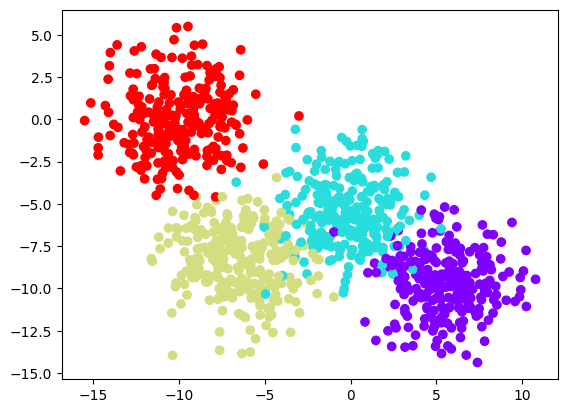

In [49]:
plt.scatter(data[0][:,0], data[0][:,1],c=clf1.predict(data[0]), cmap='rainbow')

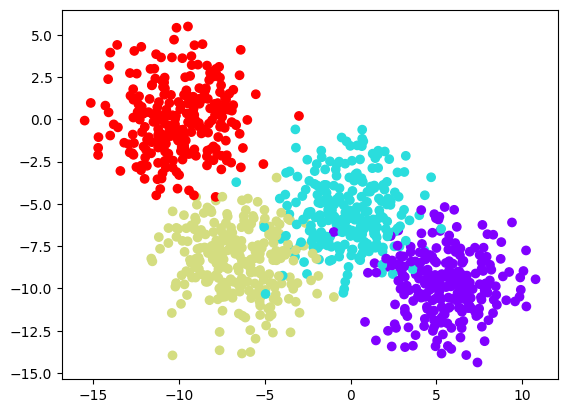

In [41]:
plt.scatter(data[0][:,0], data[0][:,1],c=clf2.predict(data[0]), cmap='rainbow')

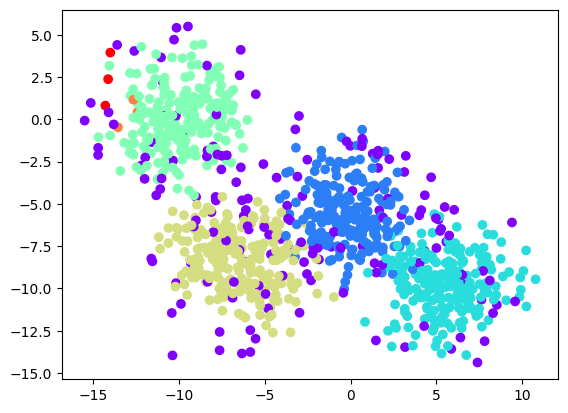

In [56]:
plt.scatter(data[0][:,0], data[0][:,1],c=clf3.labels_, cmap='rainbow')

In [57]:
# DBSCAN vs. KNN/SVC: Why DBSCAN results may seem 'worse'

# 1. Supervised vs. Unsupervised Learning:
#    - KNN (K-Nearest Neighbors) and SVC (Support Vector Classifier) are **supervised learning** algorithms.
#      They learn from labeled data (X_train, y_train) to predict the class of new data points.
#      Their goal is to classify data accurately based on predefined categories.
#    - DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an **unsupervised learning** algorithm.
#      It does not use any pre-existing labels. Its goal is to discover natural groupings (clusters) in the data
#      based on data density, and to identify outliers (noise).

# 2. Parameter Sensitivity:
#    - DBSCAN's performance is highly dependent on its two main parameters: `eps` (maximum distance between samples
#      for one to be considered as in the neighborhood of the other) and `min_samples` (the number of samples
#      in a neighborhood for a point to be considered as a core point).
#    - If `eps` and `min_samples` are not chosen carefully (often requiring domain knowledge or trial-and-error),
#      DBSCAN might identify too many noise points (-1 labels) or merge distinct clusters, leading to results
#      that don't align with known class labels.

# 3. Handling of 'Noise':
#    - DBSCAN explicitly identifies 'noise' points (labeled as -1). In classification, every point is assigned to a class.
#      While noise detection can be beneficial, if many points are labeled as noise, it reduces the number of points
#      assigned to meaningful clusters, which might be interpreted as 'worse' when comparing to a perfect classification.

# 4. Nature of Clusters:
#    - DBSCAN is particularly effective at finding arbitrarily shaped clusters and clusters of varying densities.
#      However, if clusters are not dense enough or are not well-separated by sparse regions (as might be the case
#      with default parameters on the Iris dataset), it may struggle.
#    - KNN and SVC, being classifiers, are robust at finding decision boundaries between well-separated classes,
#      even if those classes aren't 'dense' in a DBSCAN sense.

# In summary: When comparing DBSCAN to supervised classifiers like KNN and SVC, it's crucial to remember that
# they serve different purposes. DBSCAN's 'worse' performance often refers to its inability to perfectly replicate
# pre-defined class labels without specific parameter tuning, not necessarily a failure of the algorithm itself
# in its intended task of density-based clustering.